In [11]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import matplotlib.font_manager as fm
import os
font_path = '/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/Helvetica.ttc'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# load data

In [13]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]



import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")


scl_multiplier = 25 # this is how much you need to multiply the original adata coords to match to the new mesh.
# # first is cut 
# dv_cutoff = 5500/scl_multiplier  # just very arbitrary to cut the results
# adata_mer = adata_mer[adata_mer.obsm['spatial'][:,1]<dv_cutoff]
# second is hemisphere
all_spatial = adata_mer.obsm['spatial'].copy()
all_spatial = processing.get_hemi(all_spatial, mesh_LC)    
# lastly scale!
all_spatial*= scl_multiplier


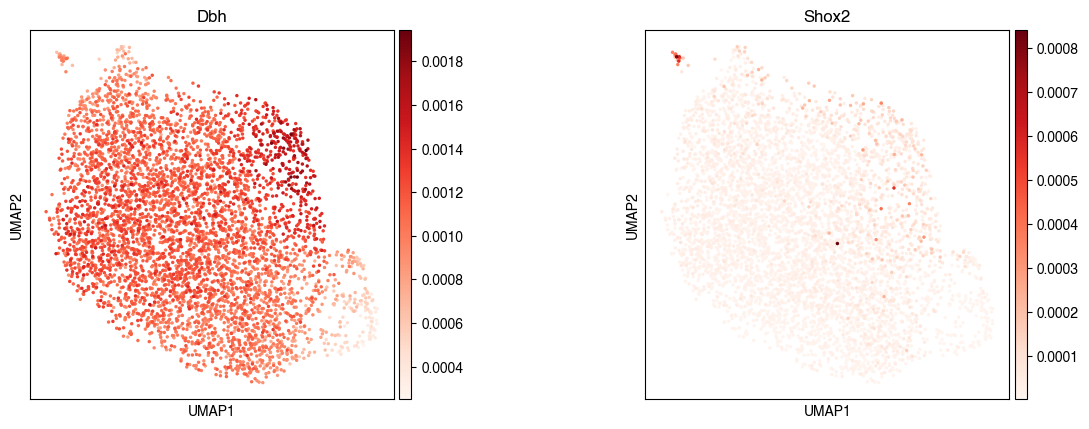

In [14]:
ax = sc.pl.umap(adata_sc,color=['Dbh','Shox2'],ncols=5,show = False, cmap = 'Reds')
for a in ax:
    a.set_aspect('equal')

# load merfish 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


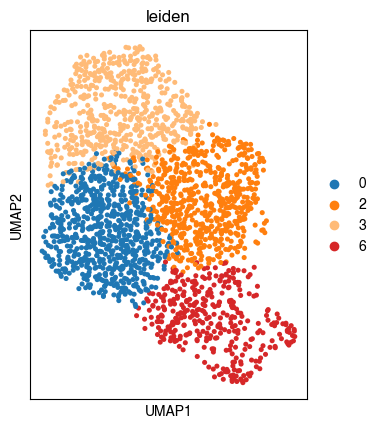

In [15]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

a = sc.pl.umap(adata_mer, color='leiden', show = False)
a.set_aspect('equal')

In [16]:
adata_mer.shape

(2252, 314)

# impute!
arc_info is saved from this notebook `all_figs_snRNA_modularized`!
(04/16)

In [17]:
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
from imputations import *

In [18]:
import pickle 
arc_info = pickle.load(open('/home/shuonan.chen/scratch_shuonan/LC_scRNAseq/arc_info_2d.pkl', 'rb'))
locals().update(arc_info)

inverse_order = np.argsort(allcells_new_order)
t_projections_original_order = t_projections[inverse_order]


In [19]:
union_genes = np.union1d(adata_sc.var_names, adata_mer.var_names)  # > n_hvg
union_genes.shape

(5126,)

In [22]:
common_genes = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
print(common_genes.shape)
adata_sc_ref = adata_sc[:, common_genes].copy()  # we will impute based on this guy, number of `union_genes=2184` will be imputed. 


(314,)


In [23]:
k = 10
X_sc = adata_sc_ref[:, common_genes].X
X_mer = adata_mer[:, common_genes].X     
X_sc_norm = processing.normalize_cols(X_sc, ranked=True)
X_mer_norm = processing.normalize_cols(X_mer, ranked=True)
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_sc_norm)
distances, indices = nbrs.kneighbors(X_mer_norm) # distance: size (N_mer, K)
epsilon = 1e-10
weights = 1 / (distances + epsilon)
weights = weights / weights.sum(axis=1, keepdims=True)  # normalize so that weights sum to 1

In [24]:
imputed_t_loc = np.zeros((adata_mer.n_obs))
for i in range(adata_mer.n_obs):
    neighbor_idx = indices[i]    
    imputed_t_loc[i] = np.dot(weights[i], t_projections_original_order[neighbor_idx])

In [27]:
imputed_t_loc

array([0.34623573, 0.39955502, 0.29547284, ..., 0.55066707, 0.41596078,
       0.53095826])

In [25]:
all_spatial.shape, imputed_t_loc.shape

((2252, 3), (2252,))

In [26]:
fig_path = '/home/shuonan.chen/scratch_shuonan/fig_making_LCNE/june_2025/'
plt.rcParams.update({
    "svg.fonttype": 'none',
    "pdf.fonttype": 42,
    'ps.fonttype':42
})


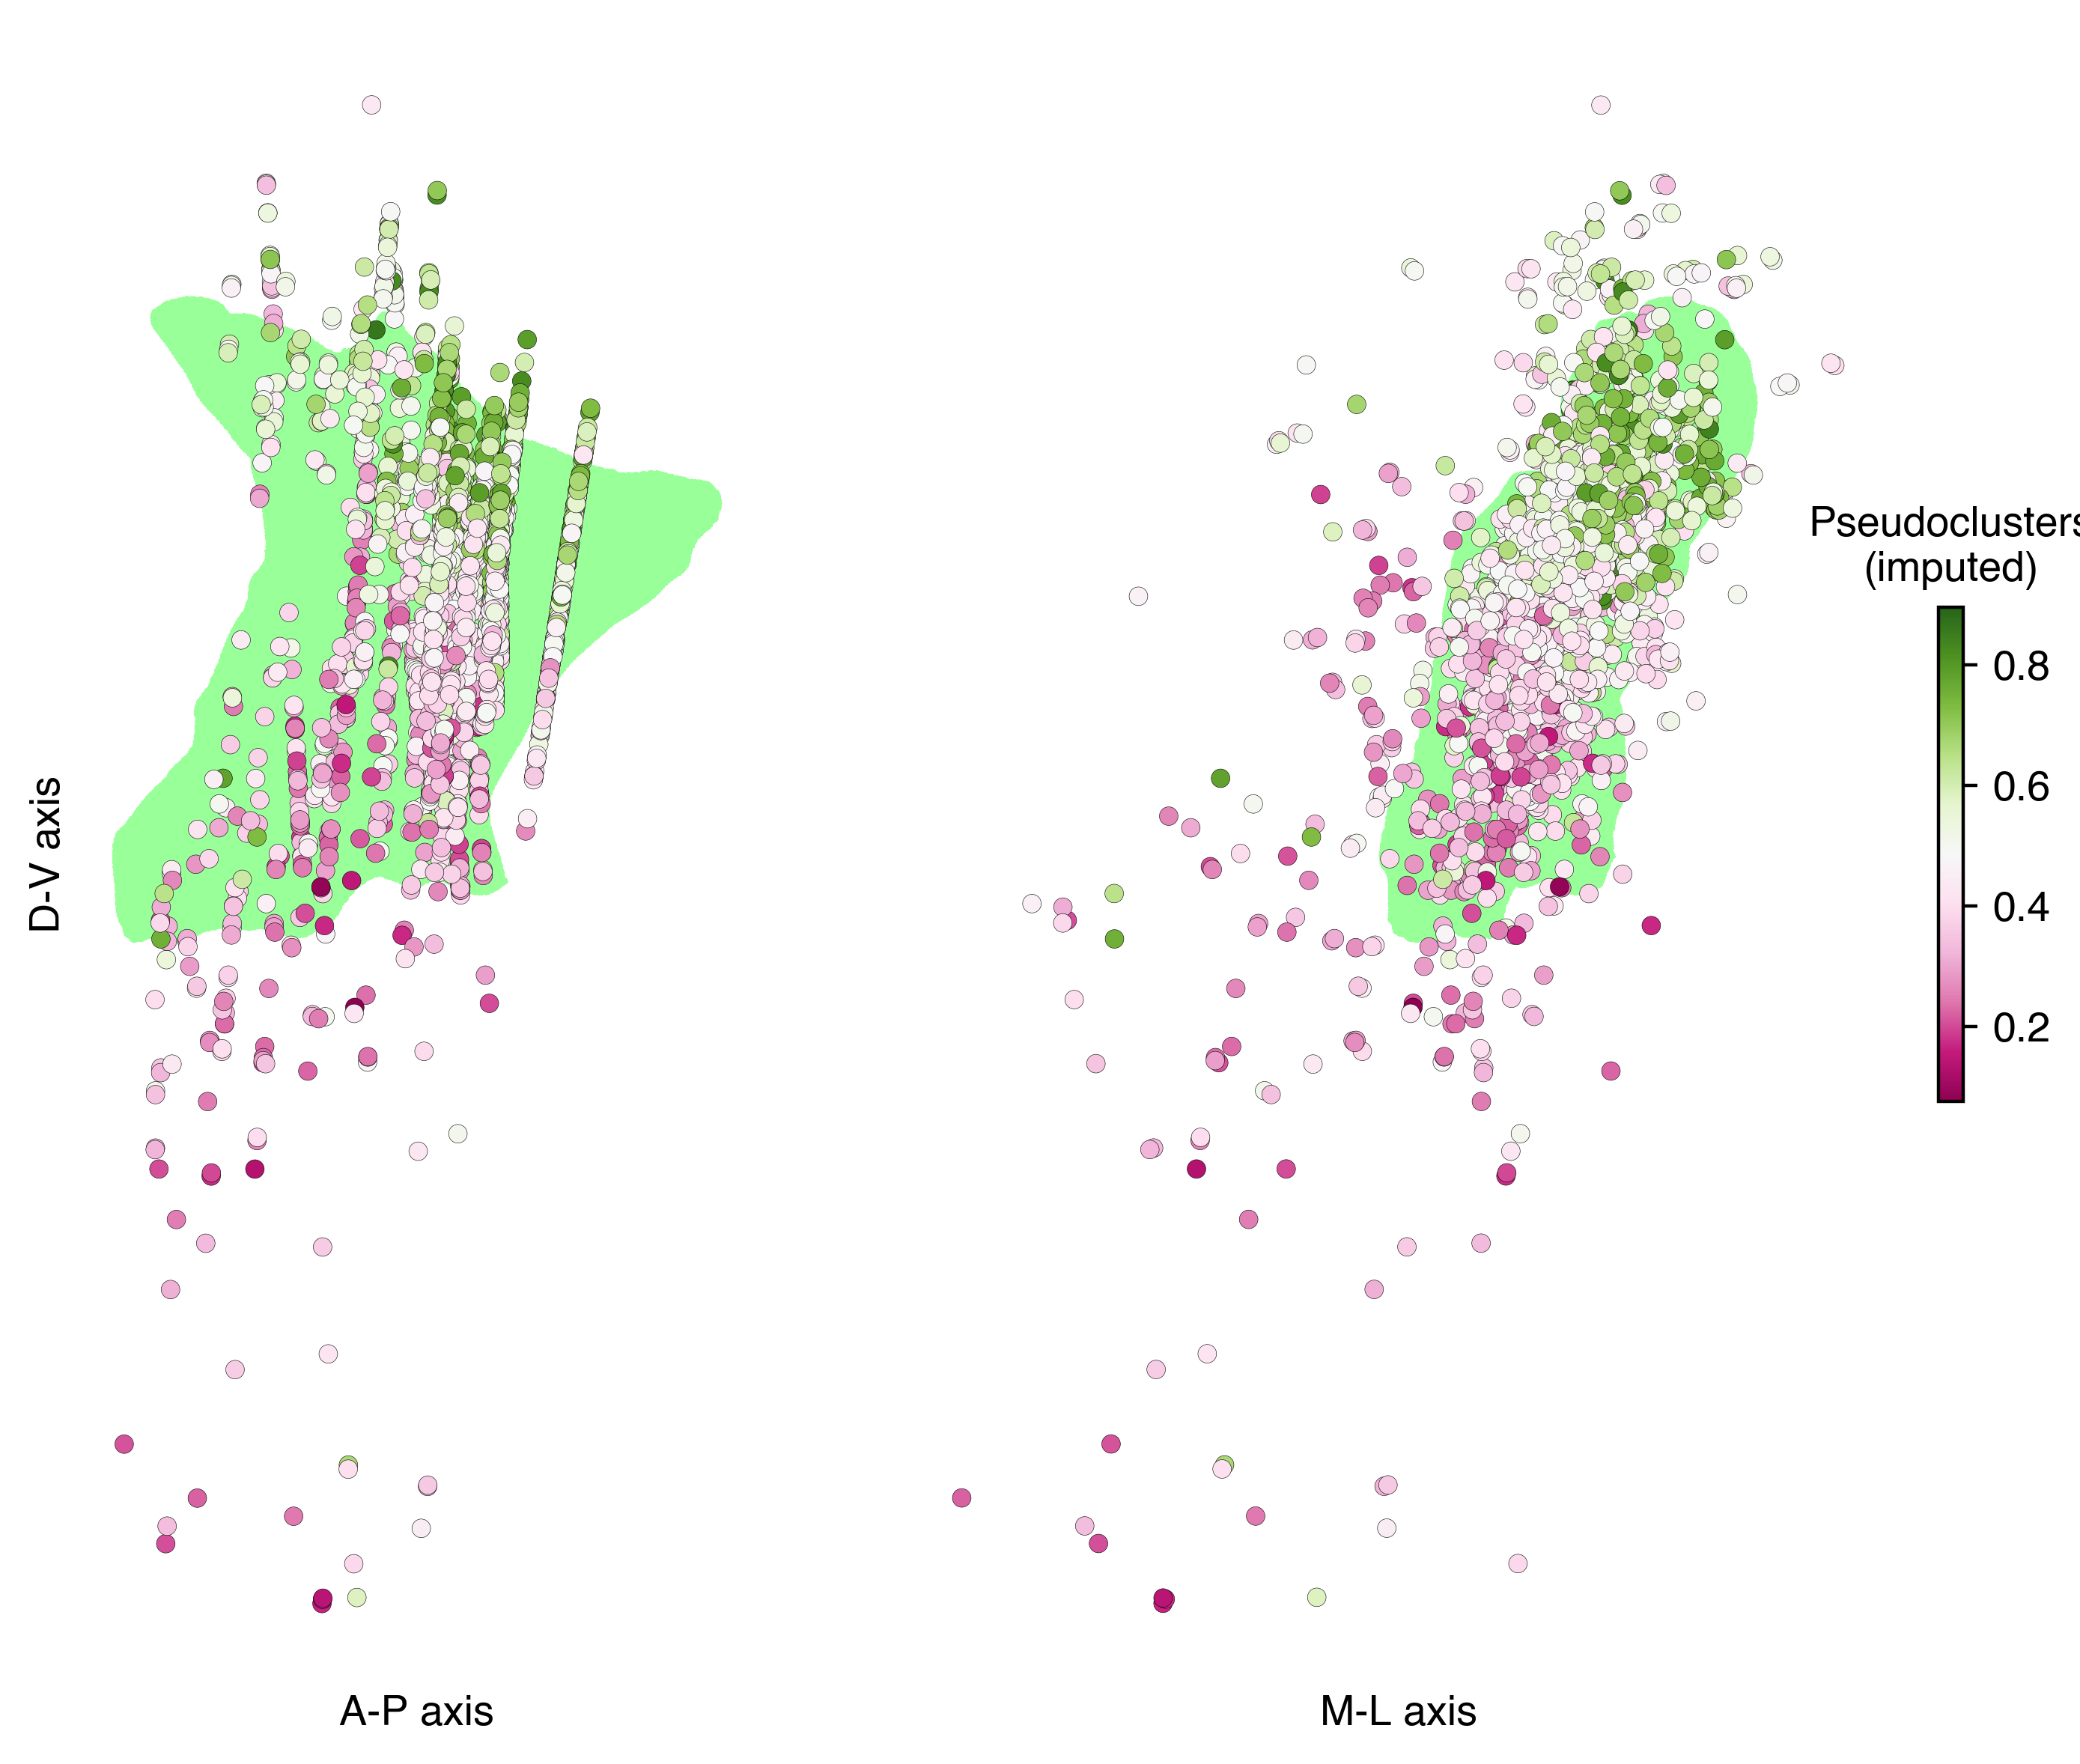

In [21]:
s=20
meshes = utils.load_mesh()
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 6),
    gridspec_kw={'width_ratios': [1, 1]}
)
plotting.plot_mesh(ax1, allmeshes,direction = 's', meshcol='lime')
sca = ax1.scatter(all_spatial[:,0],all_spatial[:,1],
                  cmap ='PiYG',s =s,edgecolor='black',lw=.1,
                  c =imputed_t_loc)    
ax1.set_ylabel("D-V axis");
ax1.set_xlabel("A-P axis") 
ax1.set_xticks([]);ax1.set_yticks([]);
for spine in ax1.spines.values():
    spine.set_visible(False)
plotting.plot_mesh(ax2, allmeshes,direction = 'c', meshcol='lime')
sca = ax2.scatter(all_spatial[:,2],all_spatial[:,1],
                  cmap ='PiYG',s =s,edgecolor='black',lw=.1,
                  c =imputed_t_loc) 
cbar = plt.colorbar(sca, ax=ax2,  shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f"Pseudoclusters\n(imputed)", ha='center', va='bottom')

ax2.set_xlabel("M-L axis") 
ax2.set_xticks([]);ax2.set_yticks([]);
for spine in ax2.spines.values():
    spine.set_visible(False)
    
fig.tight_layout()
fig.set_dpi(400)  # set dpi for the entire figure
plt.savefig(fig_path+"merfish_pc.svg", format="svg")